# Insurance Cost Prediction

## Project Overview

The objective of this project is to develops a supervised machine learning solution to predict **individual medical insurance charges** from demographic, health, and lifestyle attributes.

### Objective
Estimate expected insurance charges from:
- Age
- Sex
- BMI
- Number of childrens
- Smoking status
- Region

### Machine Learning Task
**Regression** — the target variable `charges` is continuous.

### Workflow
1. Data loading and validation
2. Data-quality
3. Exploratory Data Analysis (EDA)
4. Feature preprocessing
5. Baseline and machine learning model development
6. Cross-validation and model comparison
7. Hyperparameter tuning
8. Final test evaluation
9. Residual and analysis
10. Conclusion and limitations

In [1]:
# pip install xgboost

In [2]:
# Installation of Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Dataset Loading and Validation

### 1.1 Data Loading

In [3]:
data_path='/Users/prathameshshivshankardushetwar/Data Science/Datamites Projects/Insurance Cost Prediction/Data/datasets_13720_18513_insurance(1).csv'

data=pd.read_csv(data_path)

print(f'Dataset Shape: {data.shape[0]:,} rows x {data.shape[1]} columns')
data.head()

Dataset Shape: 1,338 rows x 7 columns


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,"16,884.924"
1,18,male,33.770,1,no,southeast,"1,725.552"
2,28,male,33.000,3,no,southeast,"4,449.462"
3,33,male,22.705,0,no,northwest,"21,984.471"
4,32,male,28.880,0,no,northwest,"3,866.855"


### 1.2 Data Validation

The first validation step is to checks data structure, data types, any missing values, data duplicates, and basic numerical statistics.

In [4]:
def data_quality_report(data):
    report = pd.DataFrame({
        'dtypes': data.dtypes.astype(str),
        'missing_count':data.isna().sum(),
        'missing_%': data.isna().mean().mul(100).round(2),
        'unique_values':data.nunique(),
        'duplicate_count':data.duplicated().sum()})
    return report

data_quality_report(data)

,dtypes,missing_count,missing_%,unique_values,duplicate_count
age,int64,0,0.000,47,1
sex,object,0,0.000,2,1
bmi,float64,0,0.000,548,1
children,int64,0,0.000,6,1
smoker,object,0,0.000,2,1
region,object,0,0.000,4,1
charges,float64,0,0.000,1337,1


In [5]:
data.info()
display(data.describe(include='all').T)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"1,338.000",NaN,NaN,NaN,39.207,14.050,18.000,27.000,39.000,51.000,64.000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,"1,338.000",NaN,NaN,NaN,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,"1,338.000",NaN,NaN,NaN,1.095,1.205,0.000,0.000,1.000,2.000,5.000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,"1,338.000",NaN,NaN,NaN,"13,270.422","12,110.011","1,121.874","4,740.287","9,382.033","16,639.913","63,770.428"


#### Categorical Variables – Unique Values & Frequency Distribution

In [6]:
def categorical_summary(data, columns):
    summary = []

    for col in columns:
        summary.append({
            'Column': col,
            'Unique Values': data[col].unique().tolist(),
            'Number of Unique': data[col].nunique(),
            'Value Counts': data[col].value_counts().to_dict()
        })
        
    return pd.DataFrame(summary)

In [7]:
categorical_cols = ['sex', 'smoker', 'region']

categorical_summary(data, categorical_cols)

,Column,Unique Values,Number of Unique,Value Counts
0,sex,"[female, male]",2,"{'male': 676, 'female': 662}"
1,smoker,"[yes, no]",2,"{'no': 1064, 'yes': 274}"
2,region,"[southwest, southeast, northwest, northeast]",4,"{'southeast': 364, 'southwest': 325, 'northwes..."


Identified unique categories and their frequency distribution for each categorical column.

## 2. Data Quality

In [8]:
print('Duplicate Rows:', data.duplicated().sum())
print('Missing values by column:')
display(data.isna().sum().to_frame('missing_count'))

# Removed duplicate rows:
data=data.drop_duplicates().reset_index(drop=True)

print(f'shape after duplicate removal : {data.shape}')

Duplicate Rows: 1
Missing values by column:


,missing_count
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


shape after duplicate removal : (1337, 7)


#### Data quality findings :

The dataset contains no missing values. One exact duplicate observation is present and is removed before modeling.

## 3. Exploratory Data Analysis (EDA)

EDA is structured into four parts:

- **Univariate analysis:** understand individual variable distributions.
- **Categorical analysis:** understand category balance.
- **Bivariate / interaction analysis:** examine relationships with `charges`.
- **Statistical analysis:** correlation, group summaries, skewness, and outlier counts.

The objective is not only to create plots, but to use them to guide preprocessing and modeling decisions.

In [9]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,"16,884.924"
1,18,male,33.770,1,no,southeast,"1,725.552"
2,28,male,33.000,3,no,southeast,"4,449.462"
3,33,male,22.705,0,no,northwest,"21,984.471"
4,32,male,28.880,0,no,northwest,"3,866.855"


In [10]:
numeric_cols = ["age", "bmi", "children", "charges"]
categorical_cols = ["sex", "smoker", "region"]

display(data[numeric_cols].describe().T)
display(data[categorical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,"1,337.000",39.222,14.044,18.000,27.000,39.000,51.000,64.000
bmi,"1,337.000",30.663,6.100,15.960,26.290,30.400,34.700,53.130
children,"1,337.000",1.096,1.206,0.000,0.000,1.000,2.000,5.000
charges,"1,337.000","13,279.121","12,110.360","1,121.874","4,746.344","9,386.161","16,657.717","63,770.428"


,count,unique,top,freq
sex,1337,2,male,675
smoker,1337,2,no,1063
region,1337,4,southeast,364


### Univariate Analysis

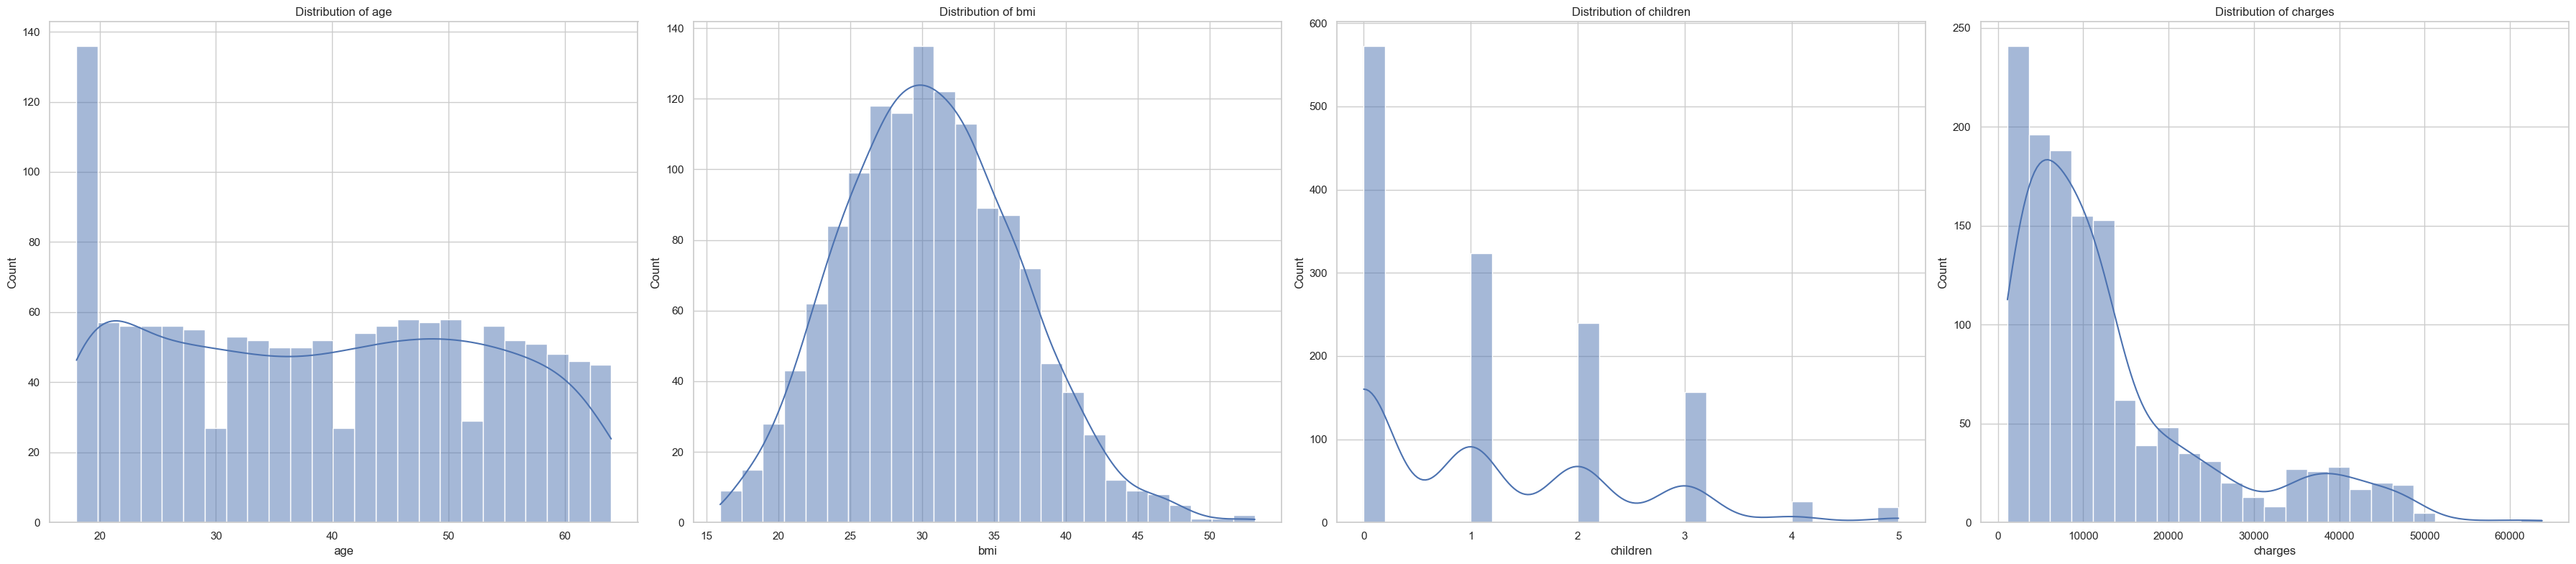

In [11]:
def plot_numeric_distributions(data, columns, bins=25):
    n = len(columns)
    fig, axes = plt.subplots(1, n, figsize=(9*n, 8))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, columns):
        sns.histplot(
            data[col].dropna(),
            bins=bins,
            kde=True,
            ax=ax
        )

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


plot_numeric_distributions(data, ["age", "bmi", "children", "charges"])

#### Univariate observations

- `age` shows most customer distributed across the adult age group population.
- `bmi` is concentrated around the central adult BMI range, with a small number of high/low observations.
- `children` is discrete and concentrated at lower counts. It helps understand the family-size pattern in the dataset.
- `charges` the distribuion of insurance charges shows the variation in medical costs among beneficiaries. it is right-skewed, with a long upper tail.

### Categorical Analysis

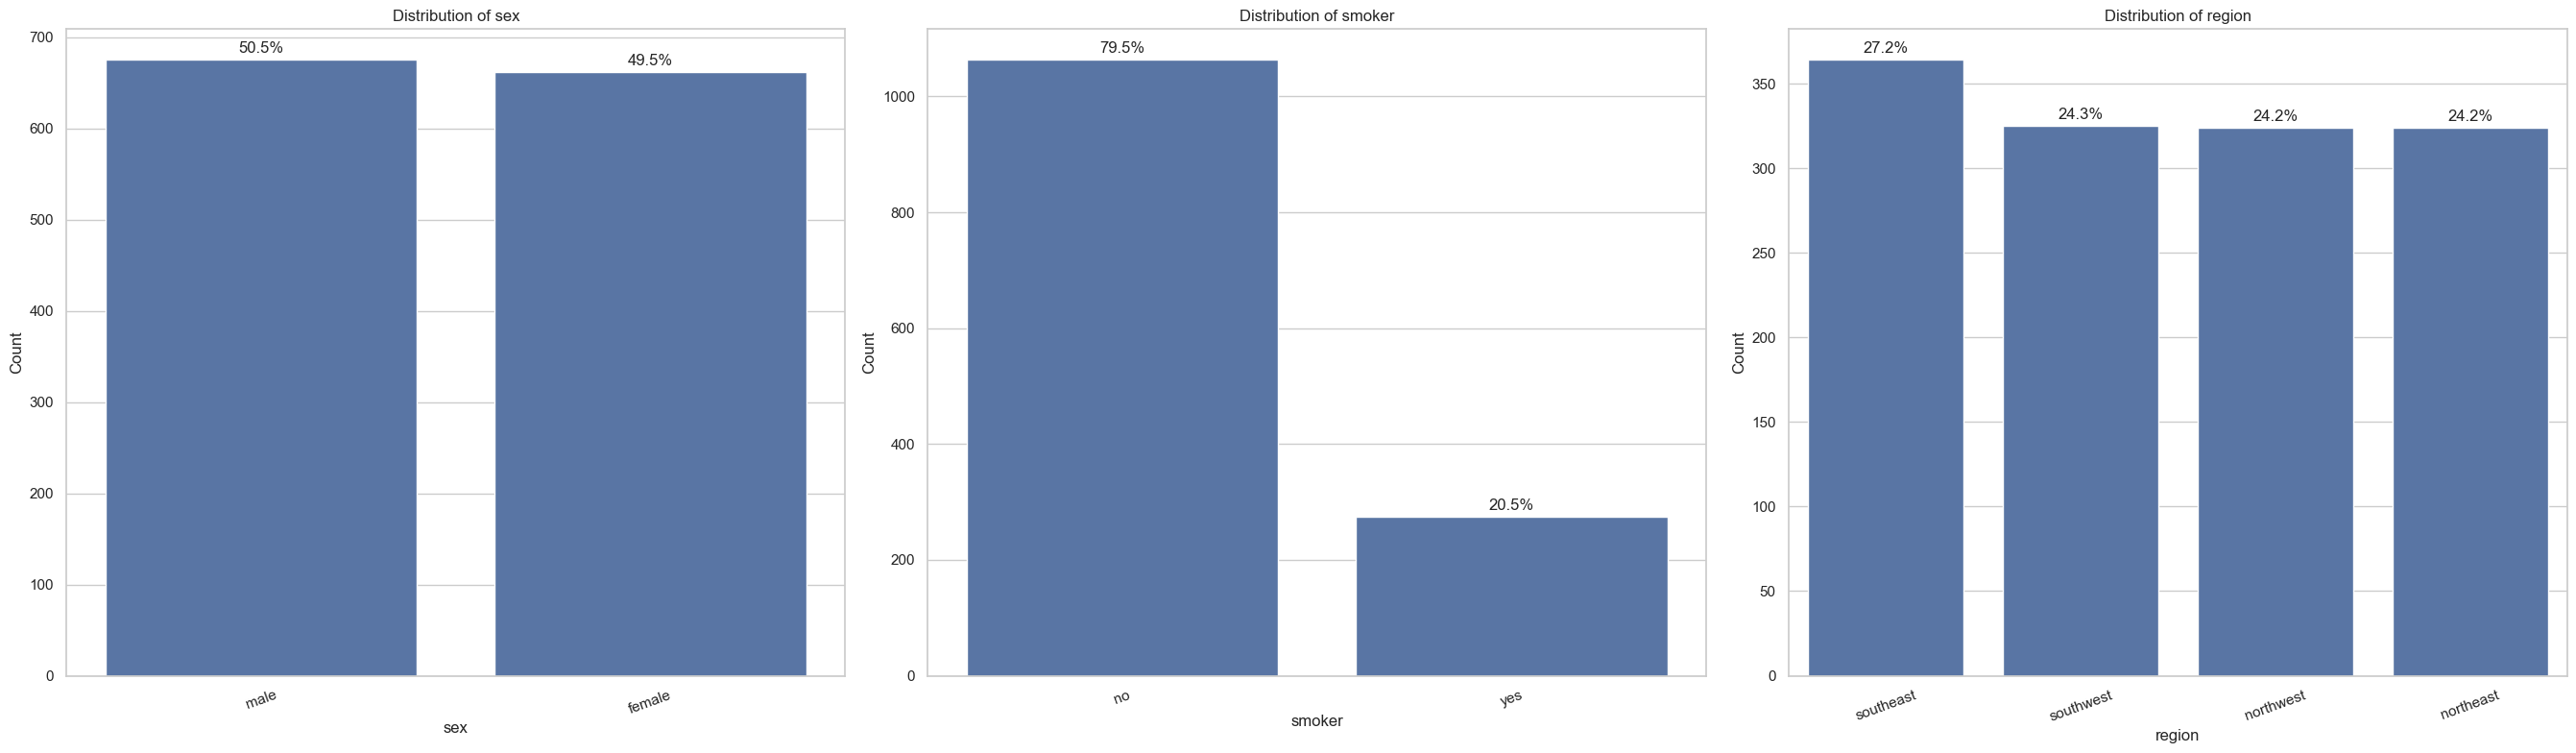

In [12]:
def plot_categorical_distributions(data, columns):
    n = len(columns)
    fig, axes = plt.subplots(1, n, figsize=(9*n, 8))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, columns):
        order = data[col].value_counts().index

        sns.countplot(data=data, x=col, order=order, ax=ax)

        # Add percentage labels
        total = len(data)
        for container in ax.containers:
            labels = [f"{(bar.get_height()/total)*100:.1f}%"
                      for bar in container]
            ax.bar_label(container, labels=labels, padding=3)

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


plot_categorical_distributions(data, ["sex", "smoker", "region"])

#### Categorical Observations

- `sex` the dataset contains two categories, male and female, with a relatively balanced distribution. This allows comparison of insurance charges across gender groups.
- `smoker` the dataset contains two categories, yes and no. Smoking status is a key segmentation variable and is expected to have a strong relationship with insurance charges.
- `region` the data is distributed across four regions — southwest, southeast, northwest, and northeast, providing regional variation for analysis.

### Bivariate Analysis

#### Bivariate Analysis with Numerical Vs Categorical Columns:

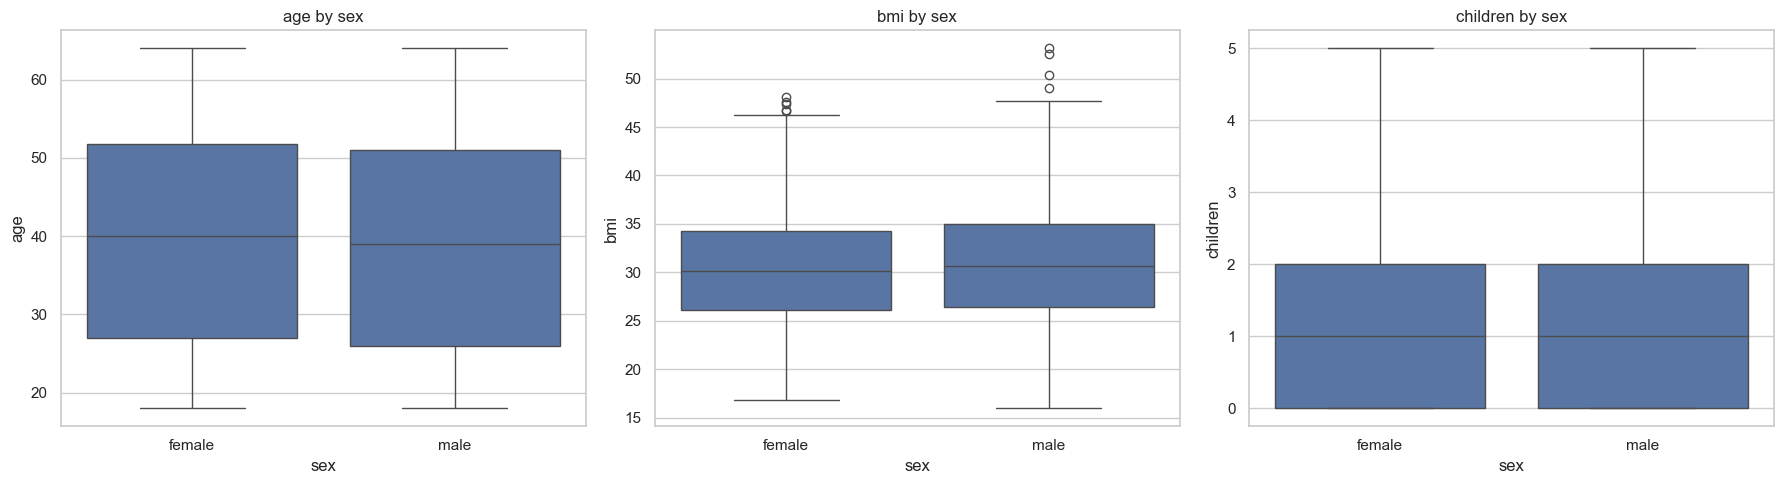

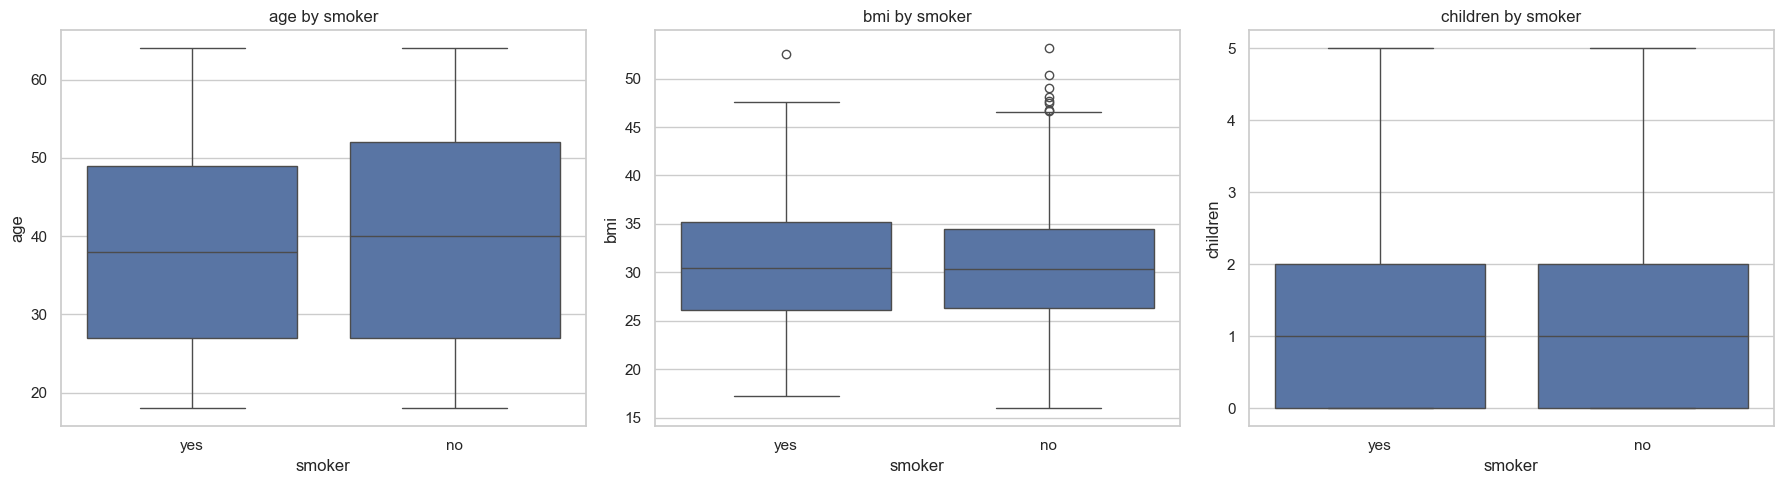

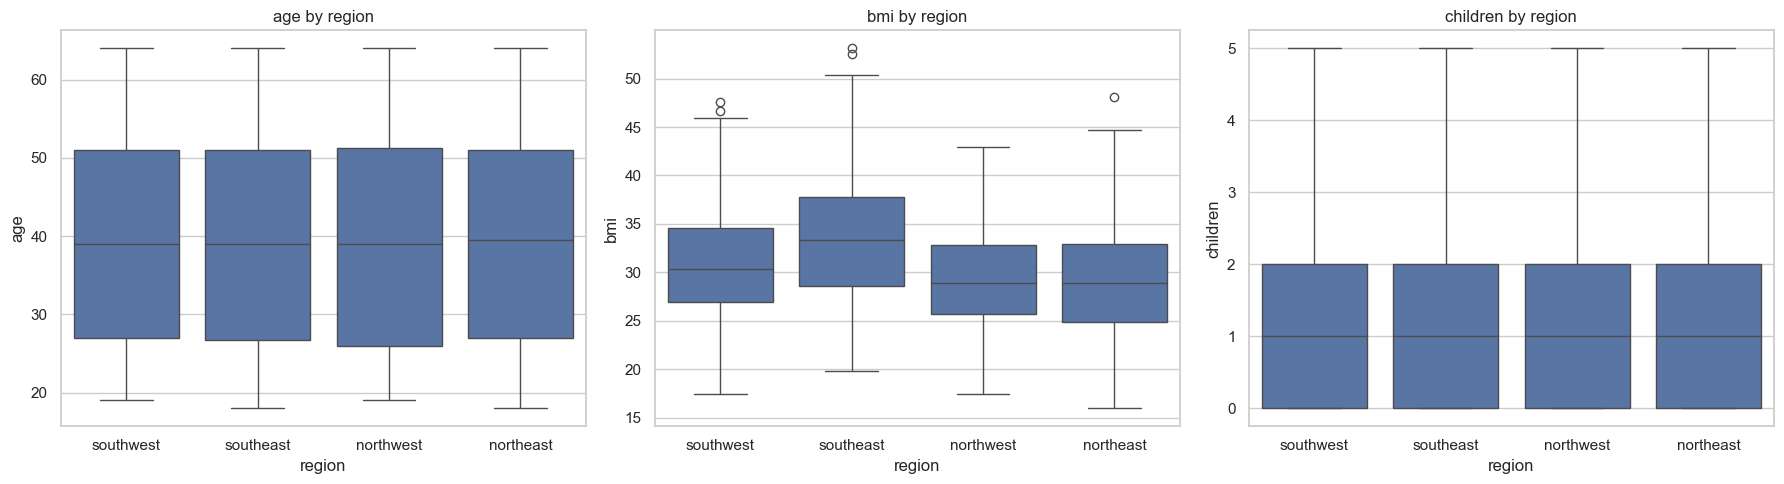

In [13]:
def plot_numeric_vs_categorical(data, numeric_cols, categorical_cols):
    for cat in categorical_cols:
        fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))

        for ax, num in zip(axes, numeric_cols):
            sns.boxplot(data=data, x=cat, y=num, ax=ax)
            ax.set_title(f"{num} by {cat}")
            ax.set_xlabel(cat)
            ax.set_ylabel(num)

        plt.tight_layout()
        plt.show()


numeric_cols = ["age", "bmi", "children"]
categorical_cols = ["sex", "smoker", "region"]

plot_numeric_vs_categorical(data, numeric_cols, categorical_cols)

#### Bivariate Observations - Numerical vs Categorical

- `Age vs sex/smoker/region` Age distributions are quite similar across all categories, with only small differences in median age.
- `BMI vs sex/smoker/region` BMI is broadly similar across groups, though some outliers are visible, especially among smokers and certain regions.
- `Region vs sex/smoker/region` Most groups have 0–2 children, with similar distributions across categories.
- `Overall` The boxplots show no strong relationship between age, BMI, or children and the categorical variables; distributions largely overlap.

#### Bivariate Analysis with Target Variable:

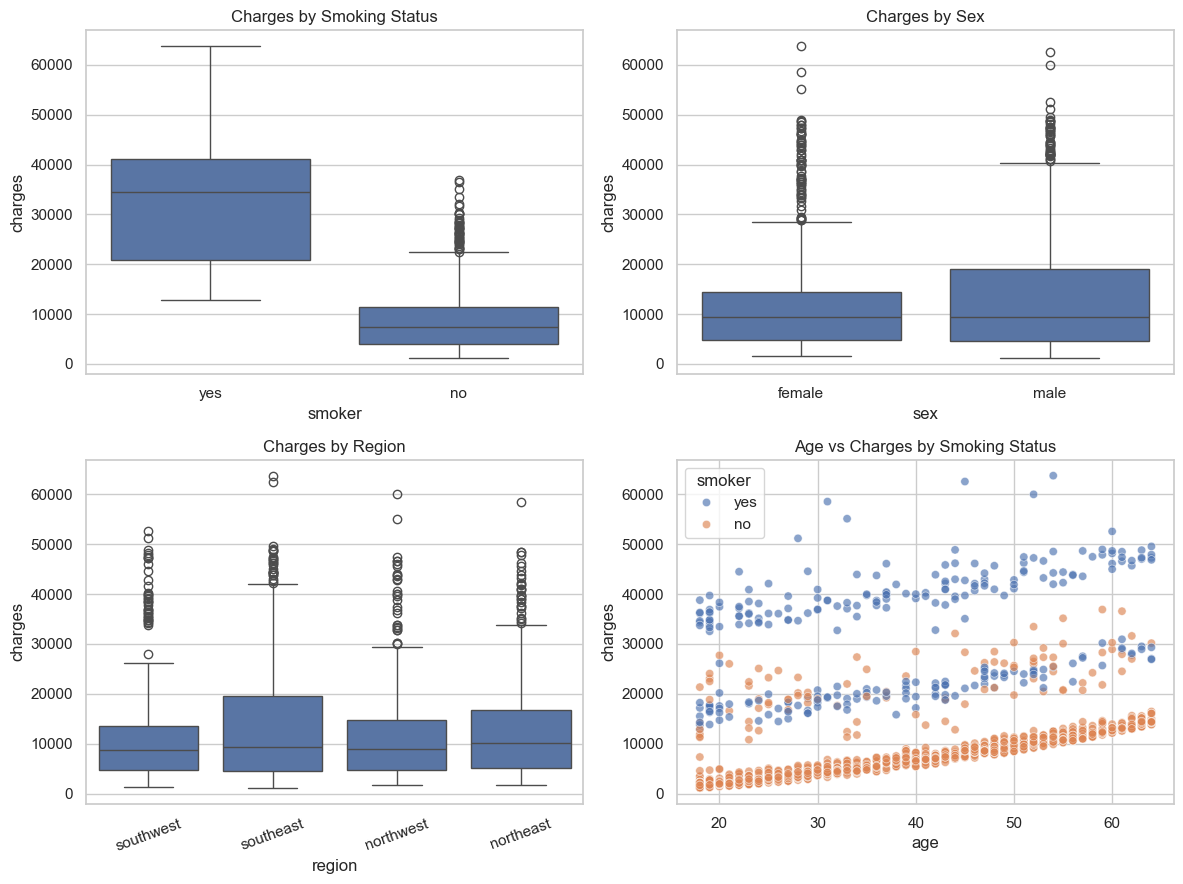

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.boxplot(data=data, x="smoker", y="charges", ax=axes[0, 0])
axes[0, 0].set_title("Charges by Smoking Status")

sns.boxplot(data=data, x="sex", y="charges", ax=axes[0, 1])
axes[0, 1].set_title("Charges by Sex")

sns.boxplot(data=data, x="region", y="charges", ax=axes[1, 0])
axes[1, 0].set_title("Charges by Region")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.scatterplot(data=data, x="age", y="charges", hue="smoker", alpha=0.65, ax=axes[1, 1])
axes[1, 1].set_title("Age vs Charges by Smoking Status")

plt.tight_layout()
plt.show()

#### Bivariate Observations – Insurance Charges

- `Charges vs Smoking Status` Smokers have much higher insurance charges than non-smokers, indicating smoking status is a strong factor affecting charges.
- `Charges vs Sex` Males show slightly higher median charges than females, but the distributions overlap considerably.
- `Charges vs Region` Insurance charges are fairly similar across regions, with some variation and several high-value outliers.
- `Age vs Charges` Insurance charges generally increase with age. The increase is much more noticeable among smokers.
- `Overall`Smoking status and age appear to have the strongest relationship with insurance charges, while sex and region show comparatively weaker differences.

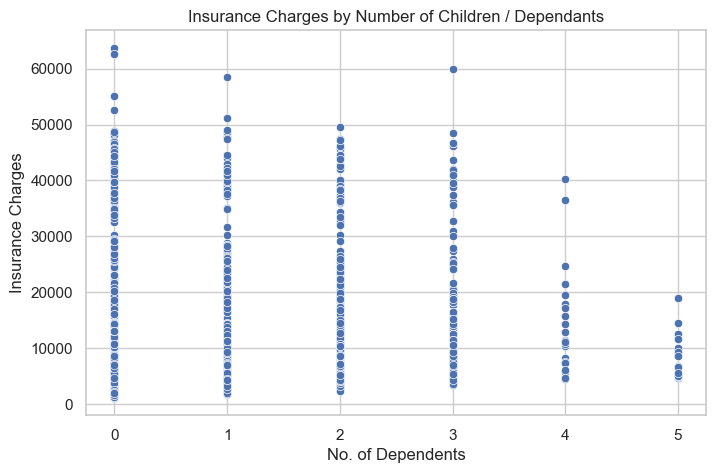

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x="children", y="charges")

plt.title("Insurance Charges by Number of Children / Dependants")
plt.xlabel("No. of Dependents")
plt.ylabel("Insurance Charges")

plt.show()

`Observation:` Insurance charges are mostly concentrated among individuals with 0–3 dependents. Although charges appear lower for 4–5 dependents, this is likely due to fewer observations. Overall, the number of dependents does not show a strong direct relationship with insurance charges, as factors like age and smoking status have a greater influence.

### Multivariate Analysis

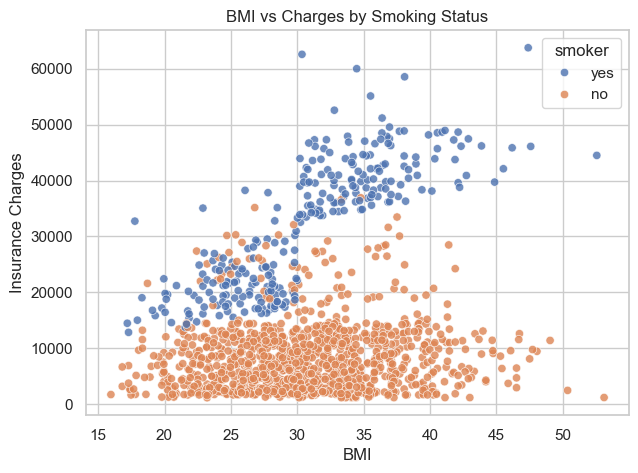

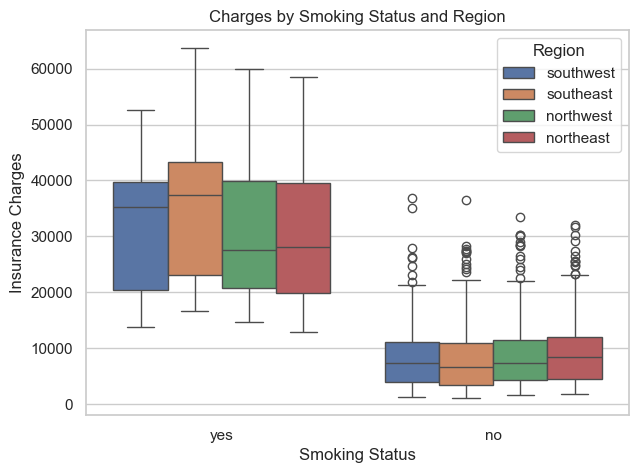

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x="bmi", y="charges", hue="smoker", alpha=0.8)
plt.title("BMI vs Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="smoker", y="charges", hue="region")
plt.title("Charges by Smoking Status and Region")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")
plt.legend(title="Region")
plt.show()

#### Multivariate Observations :

- `BMI vs Charges by Smoking Status`
Insurance charges generally increase with BMI, but the relationship is much stronger for smokers. Smokers have substantially higher charges than non-smokers across similar BMI ranges.
- `Charges by Smoking Status and Region`
Smokers have considerably higher insurance charges than non-smokers across all regions. Regional differences are relatively small compared with the effect of smoking status, although some variation and outliers are present.
- `Overall Observation`
Smoking status appears to be the most influential factor, with BMI and region contributing additional variation in insurance charges. The combination of BMI and smoking status shows a clearer relationship with insurance charges than region and smoking status.

### Correlation Analysis :

In [17]:
correlation = data.select_dtypes(include='number').corr()

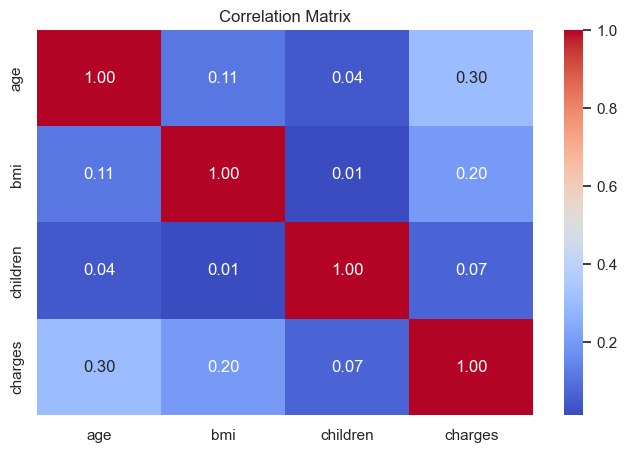

,age,bmi,children,charges
age,1.000,0.109,0.042,0.298
bmi,0.109,1.000,0.013,0.198
children,0.042,0.013,1.000,0.067
charges,0.298,0.198,0.067,1.000


In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

correlation

#### Observations :

- `Age and Charges`
Age and charges have the strongest positive correlation (0.30), indicating that charges tend to increase with age.
- `BMI and Charges` Show a weak positive correlation (0.20).
- `Children and Charges` Have a very weak correlation (0.07), suggesting little linear relationship.
- `Overall` Age has the strongest correlation with insurance charges among the numerical variables, but the correlations are not very strong

In [19]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,"16,884.924"
1,18,male,33.770,1,no,southeast,"1,725.552"
2,28,male,33.000,3,no,southeast,"4,449.462"
3,33,male,22.705,0,no,northwest,"21,984.471"
4,32,male,28.880,0,no,northwest,"3,866.855"


### Outlier Analysis

A box plot alone does not establish that an observation is erroneous. Outliers are first quantified using the IQR rule and then interpreted in context.

For this dataset:
- `bmi` has a small number of IQR-flagged observations.
- `charges` has a larger upper-tail population because the target is strongly right-skewed.
- High `charges` are plausible outcomes rather than obvious data-entry errors.

In [20]:
columns = ["age", "bmi", "children", "charges"]

result = []

for col in columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_limit) | (data[col] > upper_limit)]

    result.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Outlier Count": len(outliers)
    })

outlier_report = pd.DataFrame(result)

outlier_report

,Feature,Q1,Q3,IQR,Lower Limit,Upper Limit,Outlier Count
0,age,27.000,51.000,24.000,-9.000,87.000,0
1,bmi,26.290,34.700,8.410,13.675,47.315,9
2,children,0.000,2.000,2.000,-3.000,5.000,0
3,charges,"4,746.344","16,657.717","11,911.373","-13,120.716","34,524.778",139


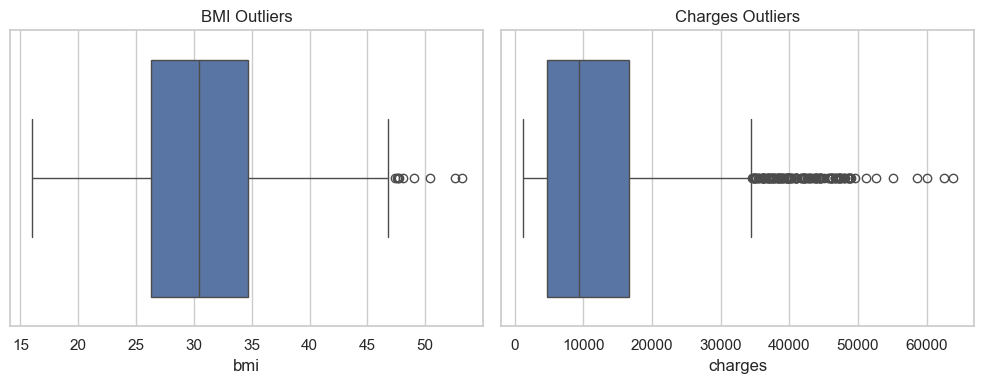

In [21]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=data["bmi"])
plt.title("BMI Outliers")

plt.subplot(1, 2, 2)
sns.boxplot(x=data["charges"])
plt.title("Charges Outliers")

plt.tight_layout()
plt.show()

### Observations

The IQR rule flags 9 BMI observations and 139 charges observations in the dataset as outliers. The outliers are retained in the dataset, as they may represent valid real-world observations.

- The insurance charges contain several high-value observations, which is consistent with the right-skewed nature of the target variable.
- No outlier removal or transformation is performed in this analysis, as these values may contain important information for predicting insurance charges.

## 4. Feature Engineering and Data Preprocessing

In [22]:
# Target Variable

x=data.drop('charges',axis=1)
y=data['charges']

# Seperate Numerical and Categorical Columns

numeric_features = ['age','bmi','children']
categorical_features = ['sex','smoker','region']

# Train and Testing Data Split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=TEST_SIZE,random_state=RANDOM_STATE)

print('Training Rows:', len(x_train))
print('Testing Rows:', len(x_test))

Training Rows: 1069
Testing Rows: 268


### Categorical Encoding

In [23]:
# Convert Categorical Variables into Numbers

x_train = pd.get_dummies(x_train, columns=categorical_features, drop_first=True)
x_test = pd.get_dummies(x_test, columns=categorical_features, drop_first=True)

# Renaming the both datasets features to same name  
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)



In [24]:
display(x_train.head())
print(x_train.shape)
print(x_test.shape)

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1113,23,24.510,0,True,False,False,False,False
967,21,25.745,2,True,False,False,False,False
598,52,37.525,2,False,False,True,False,False
170,63,41.470,0,True,False,False,True,False
275,47,26.600,2,False,False,False,False,False


(1069, 8)
(268, 8)


### Scaling of Numerical Features

In [25]:
x_train[numeric_features]

,age,bmi,children
1113,23,24.510,0
967,21,25.745,2
598,52,37.525,2
170,63,41.470,0
275,47,26.600,2
...,...,...,...
1095,51,34.960,2
1130,27,45.900,2
1294,20,22.000,1
860,38,28.000,3


In [26]:
scaler = StandardScaler()

x_train[numeric_features]=scaler.fit_transform(x_train[numeric_features])
x_test[numeric_features]=scaler.transform(x_test[numeric_features])

## 5. Model Development

The following regression algorithms are compared:

1. Linear Regression — interpretable baseline
2. Decision Tree — nonlinear single-tree model
3. Random Forest — bagging ensemble
4. Gradient Boosting — sequential boosting ensemble
5. XGBoost — optimized gradient-boosting implementation
6. KNN — distance-based model
7. SVR — kernel-based nonlinear model

### 1. Linear Regression

#### Model Building

In [27]:
# Create the model

linear_model = LinearRegression()

# Train the model

linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Model Evaluation

In [28]:
# Make Predictions

y_pred_linear=linear_model.predict(x_test)

# Calculate Evaluation Matrics

linear_mae=mean_absolute_error(y_test,y_pred_linear)
linear_mse=mean_squared_error(y_test,y_pred_linear)
linear_rmse=np.sqrt(mean_squared_error(y_test,y_pred_linear))
linear_r2=r2_score(y_test,y_pred_linear)

print('Linear Regression')
print('MAE: ',linear_mae)
print('MSE: ',linear_mse)
print('RMSE: ',linear_rmse)
print('R2 Score: ',linear_r2)



Linear Regression
MAE:  4177.045561036321
MSE:  35478020.67523557
RMSE:  5956.342894363585
R2 Score:  0.8069287081198013


### 2. Decision Tree Regressor

#### Model Building

In [29]:
# Create the model

decision_tree=DecisionTreeRegressor(random_state=42)

# Train the model

decision_tree.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


#### Model Evaluation

In [30]:
# Make predictions

y_pred_tree = decision_tree.predict(x_test)

# Calculate Evaluation Matrics

tree_mae=mean_absolute_error(y_test,y_pred_tree)
tree_mse=mean_squared_error(y_test,y_pred_tree)
tree_rmse=np.sqrt(mean_squared_error(y_test,y_pred_tree))
tree_r2=r2_score(y_test,y_pred_tree)

print('Decision Tree')
print('MAE: ',tree_mae)
print('MSE: ',tree_mse)
print('RMSE: ',tree_rmse)
print('R2 Score: ',tree_r2)


Decision Tree
MAE:  2804.8116326828363
MSE:  34953028.963362776
RMSE:  5912.108673169225
R2 Score:  0.8097857115858496


### 3. Random Forest Regressor

#### Model Building

In [31]:
# Create the model

random_forest=RandomForestRegressor(n_estimators=300,random_state=42)

# Train the model

random_forest.fit(x_train,y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Model Evaluation

In [32]:
# Make predictions

y_pred_forest = random_forest.predict(x_test)

# Calculate Evaluation Matrics

forest_mae=mean_absolute_error(y_test,y_pred_forest)
forest_mse=mean_squared_error(y_test,y_pred_forest)
forest_rmse=np.sqrt(mean_squared_error(y_test,y_pred_forest))
forest_r2=r2_score(y_test,y_pred_forest)

print('Random Forest')
print('MAE: ',forest_mae)
print('MSE: ',forest_mse)
print('RMSE: ',forest_rmse)
print('R2 Score: ',forest_r2)


Random Forest
MAE:  2644.9283867847
MSE:  22098633.921038948
RMSE:  4700.918412506108
R2 Score:  0.8797392943935918


### 4. Gradient Boosting Regressor

#### Model Building

In [33]:
# Create the model

gradient_boosting=GradientBoostingRegressor(n_estimators=100,
                                            learning_rate=0.1,
                                            random_state=42)

# Train the model

gradient_boosting.fit(x_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


#### Model Evaluation

In [34]:
# Make predictions

y_pred_gradient = gradient_boosting.predict(x_test)

# Calculate Evaluation Matrics

gradient_mae=mean_absolute_error(y_test,y_pred_gradient)
gradient_mse=mean_squared_error(y_test,y_pred_gradient)
gradient_rmse=np.sqrt(mean_squared_error(y_test,y_pred_gradient))
gradient_r2=r2_score(y_test,y_pred_gradient)

print('Gradient Boosting')
print('MAE: ',gradient_mae)
print('MSE: ',gradient_mse)
print('RMSE: ',gradient_rmse)
print('R2 Score: ',gradient_r2)


Gradient Boosting
MAE:  2517.4678305027105
MSE:  18218239.91837331
RMSE:  4268.283017604774
R2 Score:  0.9008563879867466


### 5. XGBoost Regressor

#### Model Building

In [35]:
# Create the model

xgb_model=XGBRegressor(n_estimators=100,
                       learning_rate=0.1,
                       max_depth=3,
                       random_state=42)

# Train the model

xgb_model.fit(x_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


#### Model Evaluation

In [36]:
# Make predictions

y_pred_xgb = xgb_model.predict(x_test)

# Calculate Evaluation Matrics

xgb_mae=mean_absolute_error(y_test,y_pred_xgb)
xgb_mse=mean_squared_error(y_test,y_pred_xgb)
xgb_rmse=np.sqrt(mean_squared_error(y_test,y_pred_xgb))
xgb_r2=r2_score(y_test,y_pred_xgb)

print('XGBoost')
print('MAE: ',xgb_mae)
print('MSE: ',xgb_mse)
print('RMSE: ',xgb_rmse)
print('R2 Score: ',xgb_r2)


XGBoost
MAE:  2480.243324205399
MSE:  17867986.07445379
RMSE:  4227.05406571217
R2 Score:  0.9027624684513411


### 6. KNN Regressor

#### Model Building

In [37]:
# Create the model

knn_model=KNeighborsRegressor(n_neighbors=5)

# Train the model

knn_model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Model Evaluation

In [38]:
# Make predictions

y_pred_knn = knn_model.predict(x_test)

# Calculate Evaluation Matrics

knn_mae=mean_absolute_error(y_test,y_pred_knn)
knn_mse=mean_squared_error(y_test,y_pred_knn)
knn_rmse=np.sqrt(mean_squared_error(y_test,y_pred_knn))
knn_r2=r2_score(y_test,y_pred_knn)

print('KNN')
print('MAE: ',knn_mae)
print('MSE: ',knn_mse)
print('RMSE: ',knn_rmse)
print('R2 Score: ',knn_r2)


KNN
MAE:  4496.305288503731
MSE:  65007082.01080882
RMSE:  8062.696944001357
R2 Score:  0.6462316367623702


### 7. Support Vector Regresssor (SVR)

#### Model Building

In [39]:
# Create the model

svr_model = SVR(kernel='rbf')

# Train the model

svr_model.fit(x_train,y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


#### Model Evaluation

In [40]:
# Make predictions

y_pred_svr = svr_model.predict(x_test)

# Calculate Evaluation Matrics

svr_mae=mean_absolute_error(y_test,y_pred_svr)
svr_mse=mean_squared_error(y_test,y_pred_svr)
svr_rmse=np.sqrt(mean_squared_error(y_test,y_pred_svr))
svr_r2=r2_score(y_test,y_pred_svr)

print('SVR')
print('MAE: ',svr_mae)
print('MSE: ',svr_mse)
print('RMSE: ',svr_rmse)
print('R2 Score: ',svr_r2)


SVR
MAE:  9261.820813731363
MSE:  208257131.33082858
RMSE:  14431.11677351509
R2 Score:  -0.13333474145511315


### Model Comparision

In [41]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "KNN",
        "SVR"
    ],
    
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae,
        gradient_mae,
        xgb_mae,
        knn_mae,
        svr_mae
    ],

    "MSE": [
        linear_mse,
        tree_mse,
        forest_mse,
        gradient_mse,
        xgb_mse,
        knn_mse,
        svr_mse
    ],
    
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse,
        gradient_rmse,
        xgb_rmse,
        knn_rmse,
        svr_rmse
    ],
    
    "R2": [
        linear_r2,
        tree_r2,
        forest_r2,
        gradient_r2,
        xgb_r2,
        knn_r2,
        svr_r2
    ]
})

model_results = model_results.sort_values("RMSE").reset_index(drop=True)

display(model_results.round(3))

,Model,MAE,MSE,RMSE,R2
0,XGBoost,"2,480.243","17,867,986.074","4,227.054",0.903
1,Gradient Boosting,"2,517.468","18,218,239.918","4,268.283",0.901
2,Random Forest,"2,644.928","22,098,633.921","4,700.918",0.880
3,Decision Tree,"2,804.812","34,953,028.963","5,912.109",0.810
4,Linear Regression,"4,177.046","35,478,020.675","5,956.343",0.807
5,KNN,"4,496.305","65,007,082.011","8,062.697",0.646
6,SVR,"9,261.821","208,257,131.331","14,431.117",-0.133


## 6. Cross-Validation

In [42]:
# Fold Cross Validation for XGBoost :

from sklearn.model_selection import cross_val_score, KFold

# create 5 folds
cv = KFold(n_splits=5, shuffle = True, random_state=RANDOM_STATE)

# Perform Cross Validation
cv_scores=cross_val_score(xgb_model,x_train,y_train,cv=cv,scoring="r2")

print("R2 scores for each fold:", cv_scores)
print("Mean R2:",cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R2 scores for each fold: [0.82477497 0.83460386 0.88767972 0.80973829 0.84578775]
Mean R2: 0.8405169183705847
Standard Deviation: 0.02639018094865578


In [43]:
rmse_scores = cross_val_score(xgb_model, x_train, y_train, cv=cv, scoring = "neg_root_mean_squared_error")

# convert negative values to positive

rmse_scores=-rmse_scores

print("RMSE scores for each fold:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())


RMSE scores for each fold: [4701.9505614  4574.27657807 4311.48681295 4875.47094162 4653.18043697]
Mean RMSE: 4623.273066201752
Standard Deviation: 184.55334784816895


#### Check XGBoost Overfiting

In [44]:
# Predictions on training data 
xgb_train_pred = xgb_model.predict(x_train)

# Predictions on testing data
xgb_test_pred = xgb_model.predict(x_test)

# Training R2
train_r2 = r2_score(y_train,xgb_train_pred)

# Testing R2
test_r2 = r2_score(y_test,xgb_test_pred)

# RMSE_train
train_rmse=np.sqrt(mean_squared_error(y_train, xgb_train_pred))

# RMSE test
test_rmse=np.sqrt(mean_squared_error(y_test, xgb_test_pred))

print("Training R2:", train_r2)
print("Testing R2:", test_r2)
print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)


Training R2: 0.8836376005880799
Testing R2: 0.9027624684513411
Training RMSE: 3991.455815845167
Testing RMSE: 4227.05406571217


#### Observations :

- XGBoost achieved a mean cross-validation R² of 0.84 with a standard deviation of 0.026 across five folds.
- The model showed relatively consistent performance across the folds.
- The training and testing performance were also similar, with training R² score of 0.88 and testing R² score of 0.90, while the training and testing RMSE values were 3991.45 and 4,227.05 respectively.

Therefore, there is no clear indication of significant overfitting in the current XGBoost model.

## 7. Hyperparameter Tunning

#### Using Grid Search CV

In [45]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor

# Create XGBoost Model

xgb_model_grid = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE)

# Define the parameters

param_grid={'n_estimators': [100,200,300,400],
           'learning_rate': [0.03,0.05,0.1],
           'max_depth': [2,3,4],
           'subsample': [0.8,1.0],
           'colsample_bytree':[0.8,1.0]}

# Create GridSearchCV

xgb_grid=GridSearchCV(estimator=xgb_model_grid,
                     param_grid=param_grid,
                     scoring='neg_root_mean_squared_error',
                     cv=5,
                     n_jobs=-1)

# Run the Tunning

xgb_grid.fit(x_train,y_train)

# Extract the best Parameters :

print("Best Parameters")
print(xgb_grid.best_params_)

# See Best CV RMSE :

print("Best CV RMSE:", -xgb_grid.best_score_)

Best Parameters
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}
Best CV RMSE: 4578.7585904166845


In [46]:
## Get the Tuned Model :

tuned_xgb_model_grid = xgb_grid.best_estimator_
tuned_pred_grid=tuned_xgb_model_grid.predict(x_test)

# Evaluate the Tuned Model :

tuned_mae_grid = mean_absolute_error(y_test, tuned_pred_grid)
tuned_mse_grid = mean_squared_error(y_test, tuned_pred_grid)
tuned_rmse_grid = np.sqrt(tuned_mse_grid)
tuned_r2_grid = r2_score(y_test, tuned_pred_grid)

print("Tuned XGBoost_Grid")
print("MAE :", tuned_mae_grid)
print("MSE :", tuned_mse_grid)
print("RMSE:", tuned_rmse_grid)
print("R2  :", tuned_r2_grid)

Tuned XGBoost_Grid
MAE : 2493.117640282241
MSE : 18178368.91912888
RMSE: 4263.609846025886
R2  : 0.9010733658560348


#### Using Random Search CV

In [47]:
# Import RandomSearchCV

from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBRegressor

# Create XGBoost Model

xgb_model_random = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE)

# Define the parameters

param_grid={'n_estimators': [100,200,300,400,500],
           'learning_rate': [0.1,0.03,0.05,0.1],
           'max_depth': [2,3,4,5],
           'subsample': [0.7,0.8,0.9,1.0],
           'colsample_bytree':[0.7,0.8,0.9,1.0]}

# Create RandomSearchCV

xgb_random=RandomizedSearchCV(estimator=xgb_model_random,
                     param_distributions=param_grid,
                     n_iter=30,
                     scoring='neg_root_mean_squared_error',
                     cv=5,
                     random_state=RANDOM_STATE,
                     n_jobs=-1)

# Run the Tunning

xgb_random.fit(x_train,y_train)

# Extract the best Parameters :

print("Best Parameters")
print(xgb_random.best_params_)

# See Best CV RMSE :

print("Best CV RMSE:", -xgb_random.best_score_)

Best Parameters
{'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV RMSE: 4586.038936528359


In [48]:
## Get the Tuned Model :

tuned_xgb_model_random = xgb_random.best_estimator_
tuned_pred_random=tuned_xgb_model_random.predict(x_test)

# Evaluate the Tuned Model :

tuned_mae_random = mean_absolute_error(y_test, tuned_pred_random)
tuned_mse_random = mean_squared_error(y_test, tuned_pred_random)
tuned_rmse_random = np.sqrt(tuned_mse_random)
tuned_r2_random = r2_score(y_test, tuned_pred_random)

print("Tuned XGBoost Random")
print("MAE :", tuned_mae_random)
print("MSE :", tuned_mse_random)
print("RMSE:", tuned_rmse_random)
print("R2  :", tuned_r2_random)

Tuned XGBoost Random
MAE : 2459.0121786873838
MSE : 17903137.041191053
RMSE: 4231.209879123352
R2  : 0.9025711769861005


In [49]:
## Original vs Tuned Model Metrics :

comparision = pd.DataFrame({
    'Model': ['Original XGBoost', 'Tuned XGBoost Grid', 'Tuned XGBoost Random'],
    'MAE': [2480.243, tuned_mae_grid, tuned_mae_random],
    'RMSE':[4227.054, tuned_rmse_grid, tuned_rmse_random],
    'R2':[0.903, tuned_r2_grid, tuned_r2_random]
})

display(comparision.round(3))

,Model,MAE,RMSE,R2
0,Original XGBoost,"2,480.243","4,227.054",0.903
1,Tuned XGBoost Grid,"2,493.118","4,263.610",0.901
2,Tuned XGBoost Random,"2,459.012","4,231.210",0.903


### Observations :

- Hyperparameter tuning was performed on the XGBoost model using 5-fold GridSearchCV. The best parameters were selected based on cross-validation RMSE. However, when evaluated on the unseen test set, the tuned XGBoost model did not improve upon the original model.
- The original XGBoost achieved an RMSE of 4,227.05 and R² of 0.903, compared with Grid Search XGBoost an RMSE of 4,263.61 and R² of 0.901 for the tuned model.
- The Original XGBoost achieved the lowest RMSE 4,227.054 and the highest R² 0.903. Therefore, the original XGBoost model is retained as the final model.
- The Random Search XGBoost achieved the lowest MAE 2,459.012, indicating slightly lower average absolute prediction error.
- The Grid Search XGBoost did not improve the model compared with the original XGBoost.
- Overall, the three XGBoost models show very similar performance, with only small differences in their evaluation metrics. Based on the lowest RMSE and highest R², the Original XGBoost is retained as the final model.

Hyperparameter tuning did not provide a significant improvement over the original XGBoost model. Therefore, the original XGBoost model is retained as the final model for predicting insurance charges.

### Model Comparison :

In [50]:
# Original Metrics Backup

final_comparison = model_results.copy()

# Add GridSearch XGBoost

grid_row = pd.DataFrame([{
    "Model": "GridSearch XGBoost",
    "MAE": tuned_mae_grid,
    "MSE": tuned_mse_grid,
    "RMSE": tuned_rmse_grid,
    "R2": tuned_r2_grid
}])

# Add RandomSearch XGBoost

random_row = pd.DataFrame([{
    "Model": "RandomSearch XGBoost",
    "MAE": tuned_mae_random,
    "MSE": tuned_mse_random,
    "RMSE": tuned_rmse_random,
    "R2": tuned_r2_random
}])

# Combine all models

final_comparison = pd.concat(
    [final_comparison, grid_row, random_row],
    ignore_index=True
)

# Sort by RMSE

final_comparison = final_comparison.sort_values("RMSE").reset_index(drop=True)

display(final_comparison.round(3))


,Model,MAE,MSE,RMSE,R2
0,XGBoost,"2,480.243","17,867,986.074","4,227.054",0.903
1,RandomSearch XGBoost,"2,459.012","17,903,137.041","4,231.210",0.903
2,GridSearch XGBoost,"2,493.118","18,178,368.919","4,263.610",0.901
3,Gradient Boosting,"2,517.468","18,218,239.918","4,268.283",0.901
4,Random Forest,"2,644.928","22,098,633.921","4,700.918",0.880
5,Decision Tree,"2,804.812","34,953,028.963","5,912.109",0.810
6,Linear Regression,"4,177.046","35,478,020.675","5,956.343",0.807
7,KNN,"4,496.305","65,007,082.011","8,062.697",0.646
8,SVR,"9,261.821","208,257,131.331","14,431.117",-0.133


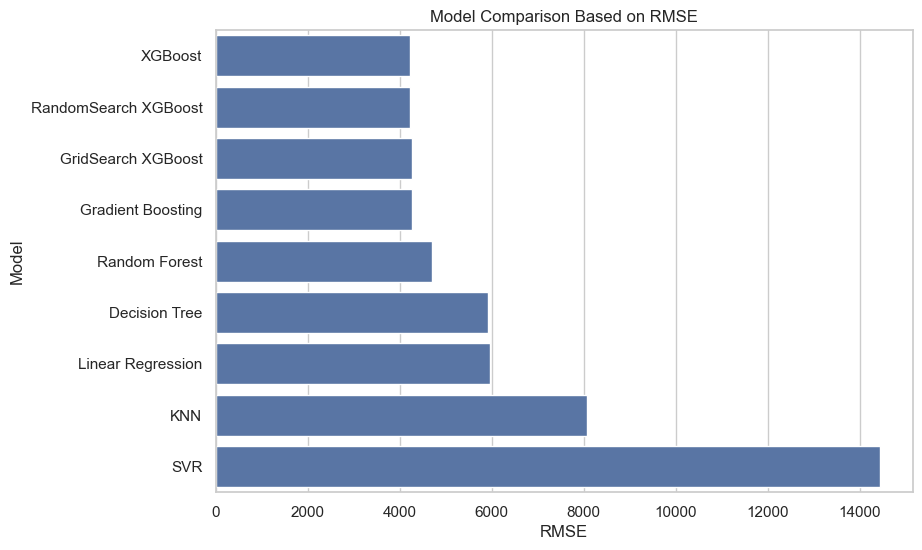

In [51]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=final_comparison,
    x="RMSE",
    y="Model"
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.show()

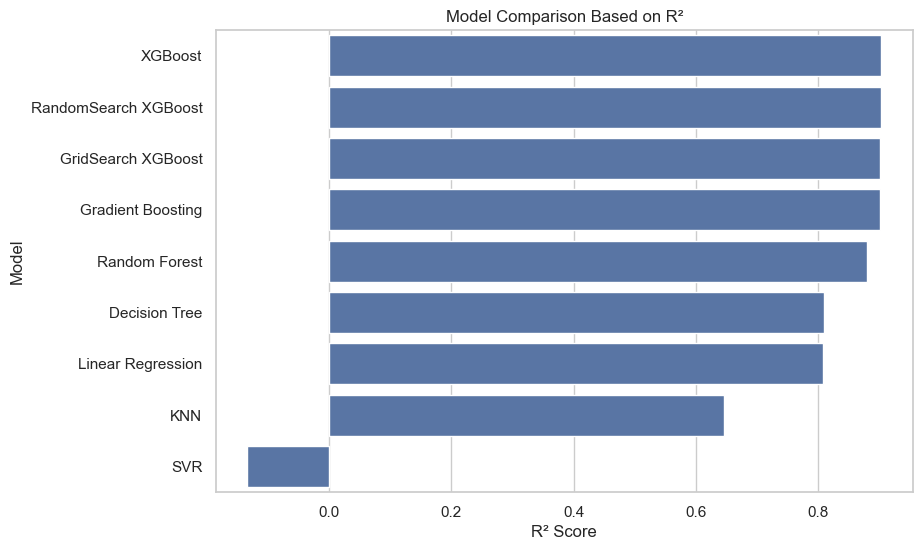

In [52]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=final_comparison,
    x="R2",
    y="Model"
)

plt.title("Model Comparison Based on R²")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

### Observations :

- The model comparison shows that XGBoost provides the best overall performance, achieving the lowest RMSE of approximately 4227.05 and an R² of approximately 0.90 The tuned XGBoost and Gradient Boosting models show similar performance, while Random Forest, Decision Tree, Linear Regression, KNN, and SVR have comparatively higher prediction errors. **Therefore, the original XGBoost model is retained as the final model for insurance charge prediction.**

## 8. Final Model Dignostic - Actual vs Predicted Graph & Residual Analysis

### Actual vs Predicted Graph :

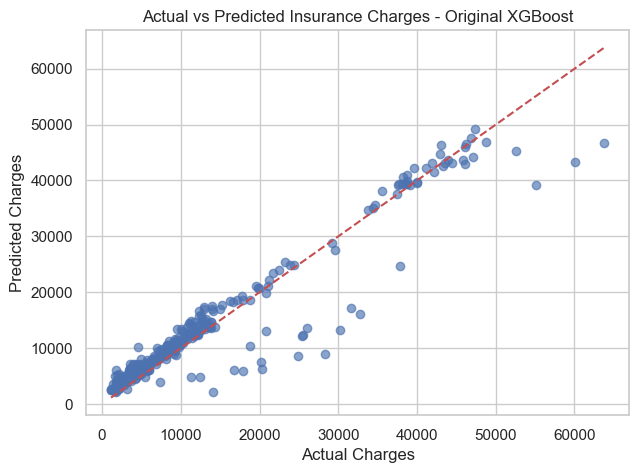

In [53]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred_xgb,alpha=0.65)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--")

plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title("Actual vs Predicted Insurance Charges - Original XGBoost")

plt.show()

### Residual Analysis :

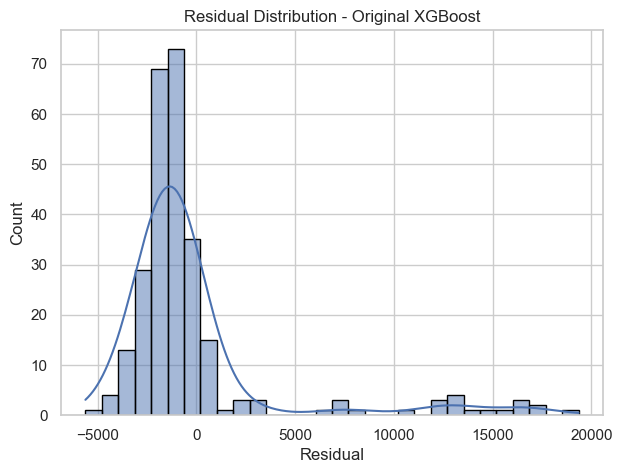

In [54]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(7,5))

sns.histplot(residuals, bins=30, edgecolor='black', kde=True)

plt.title('Residual Distribution - Original XGBoost')
plt.xlabel('Residual')
plt.ylabel('Count')

plt.show()



### Observations :

- The residual distribution shows the difference between actual charges vs the predicted charges by model.
- Here the residuals are highly concentrated around zero, indicating that the XGBoost model generally makes reasonably accurate predications. However the distribution is right_skewed with some large positive residuals, showing that the model has larger errors for few high insurance charges.

## 9. Challenges Faced

#### 1. Dataset Loading and File Path

- `Challenge:` The dataset was not initially available in the default notebook location.
- `Solution:` Identified the correct file path and loaded the dataset using pandas.
- `Learning:` Understood how to locate and load external datasets into a Python environment.

#### 2. Duplicate Records

- `Challenge:` A duplicate record was identified in the dataset.
- `Solution:` Used duplicated() to identify duplicates and drop_duplicates() to remove them.
- `Learning:` Duplicate observations can affect analysis and model training, so data quality checks are important.

#### 3. Data Preprocessing

- `Challenge:` The dataset contained categorical variables and required preparation before applying machine learning algorithms.
- `Solution:` Handled categorical variables using One-Hot Encoding and prepared numerical variables for modeling.
- `Learning:` Understood that raw data cannot always be directly given to machine learning models.

#### 4. Different Model Requirements

- `Challenge:` Different algorithms required different preprocessing approaches.For example, KNN and SVR, are sensitive to the scale of numerical features.
- `Solution:` Used StandardScaler for models where feature scaling was required.
- `Learning:` Model selection can affect the preprocessing steps required.

#### 5. XGBoost Installation and Setup

- `Challenge:` XGBoost was not initially installed in the environment, which caused an import error.
- `Solution:` Installed the XGBoost library using pip and then imported XGBRegressor.
- `Learning:` External machine learning libraries may need to be installed and configured before use.

#### 6. Outlier Detection

- `Challenge:` Outliers were identified in variables such as BMI and insurance charges. Some extreme insurance charges appeared to be genuine observations rather than data-entry errors.
- `Solution:` Used boxplots and the IQR method to identify and examine the outliers. The observations were retained rather than automatically removed.
- `Learning:` An outlier is not necessarily an error and should be examined before making changes to the dataset.

#### 7. Model Comparison

- `Challenge:` Different regression algorithms produced different prediction results.
- `Solution:` Compared models using MAE, RMSE, and R².
- `Learning:` Using multiple evaluation metrics provides a better understanding of model performance.

#### 8. Model Tuning

- `Challenge:` The initial XGBoost model performed well, but there was a possibility of improving its performance and reducing overfitting.
- `Solution:` Used GridSearchCV and RandomizedSearchCV to test different XGBoost hyperparameters.
- `Learning:` Hyperparameter tuning does not always improve test performance, so tuned models need to be compared with the original model.

#### 9. Final Model Selection

- `Challenge:` The tuned models showed performance very close to the original XGBoost model.
- `Solution:` Compared the original and tuned models using the same test-set metrics and retained the model with the better overall test performance.
- `Learning:` The most complex or tuned model is not necessarily the best model; model selection should be based on actual evaluation results.


## 10. Conclusion

- The objective of this project was to analyze the Medical Insurance dataset and develop a Machine Learning model to predict insurance charges based on customer and health-related features.
- Exploratory Data Analysis was performed to understand the distribution of variables and their relationships with insurance charges. The analysis showed that smoking status, age, and BMI have an important relationship with insurance charges, while the number of children showed a comparatively weaker relationship.
- Several regression algorithms were trained and evaluated, including Linear Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, KNN, and SVR.
- Among the evaluated models, XGBoost performed best overall. The original XGBoost model achieved an RMSE of approximately 4,227, an MAE of approximately 2,480, and an R² score of approximately 0.903 on the test dataset.
- Cross-validation was also performed to check the consistency of the XGBoost model across different data splits. The model achieved a mean cross-validation R² of approximately 0.84, showing that its performance remained reasonably consistent across the folds.
- Hyperparameter tuning was performed using both GridSearchCV and RandomizedSearchCV. The tuned models produced performance close to the original XGBoost model, but did not provide a meaningful improvement in the primary test RMSE. Therefore, the original XGBoost model was retained as the final model.
- Overall, the project demonstrates how data analysis, preprocessing, exploratory analysis, model comparison, cross-validation, hyperparameter tuning, and feature importance can be combined to build a regression model for insurance charge prediction.

In [55]:
# Create Pickle Files :

import pickle

# Pickled trained XGBooost Model :

with open('model.pkl','wb') as file:
    pickle.dump(xgb_model, file)

# Pickled Scaler :

with open('scaler.pkl','wb') as file:
    pickle.dump(scaler, file)

# Pickled the feature columns :

with open('columns.pkl','wb') as file:
    pickle.dump(x_train.columns.tolist(), file)

print("All Pickle Files Created Successfully")

All Pickle Files Created Successfully


In [56]:
# Test loading the saved files

with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("scaler.pkl", "rb") as file:
    loaded_scaler = pickle.load(file)

with open("columns.pkl", "rb") as file:
    loaded_columns = pickle.load(file)

print("Model loaded:", type(loaded_model))
print("Scaler loaded:", type(loaded_scaler))
print("Columns:", loaded_columns)

Model loaded: <class 'xgboost.sklearn.XGBRegressor'>
Scaler loaded: <class 'sklearn.preprocessing._data.StandardScaler'>
Columns: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [57]:
sample=pd.DataFrame({
    'age': [30],
    'sex': ['male'],
    'bmi': [25.5],
    'children':[1],
    'smoker':['no'],
    'region':['southeast']
})

sample

,age,sex,bmi,children,smoker,region
0,30,male,25.500,1,no,southeast


In [58]:
# categorical into dummy

sample = pd.get_dummies(sample,columns=['sex','smoker','region'], drop_first=True)

sample = sample.reindex(columns=loaded_columns, fill_value=0)

sample

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,30,25.500,1,0,0,0,0,0


In [59]:
numeric_features= ['age','bmi','children']

sample[numeric_features]=loaded_scaler.transform(sample[numeric_features])

sample

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-0.657,-0.833,-0.071,0,0,0,0,0


In [60]:
# predict insurance charges 

prediction = loaded_model.predict(sample)

print("Predicted Charges:", prediction[0])

Predicted Charges: 5653.517
